<a href="https://colab.research.google.com/github/adharsh-codes/aiml-assignment/blob/main/multiplehomeprice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("fedesoriano/electric-power-consumption")

100%|██████████| 1.36M/1.36M [00:00<00:00, 96.8MB/s]

Extracting files...


### Inspecting the downloaded dataset

Let's check what files are available in the downloaded directory to identify the main dataset file.

In [2]:
import os

# List the contents of the downloaded directory
print(os.listdir(path))

['powerconsumption.csv']


In [3]:
import pandas as pd

# Construct the full path to the CSV file
csv_file_path = os.path.join(path, 'powerconsumption.csv')

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first few rows of the DataFrame to inspect the data
print(df.head())

        Datetime  Temperature  Humidity  WindSpeed  GeneralDiffuseFlows  \
0  1/1/2017 0:00        6.559      73.8      0.083                0.051   
1  1/1/2017 0:10        6.414      74.5      0.083                0.070   
2  1/1/2017 0:20        6.313      74.5      0.080                0.062   
3  1/1/2017 0:30        6.121      75.0      0.083                0.091   
4  1/1/2017 0:40        5.921      75.7      0.081                0.048   

   DiffuseFlows  PowerConsumption_Zone1  PowerConsumption_Zone2  \
0         0.119             34055.69620             16128.87538   
1         0.085             29814.68354             19375.07599   
2         0.100             29128.10127             19006.68693   
3         0.096             28228.86076             18361.09422   
4         0.085             27335.69620             17872.34043   

   PowerConsumption_Zone3  
0             20240.96386  
1             20131.08434  
2             19668.43373  
3             18899.27711  
4     

In [4]:
# Convert 'Datetime' column to datetime objects and set it as the index
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')

# Display info to check data types and non-null values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52416 entries, 2017-01-01 00:00:00 to 2017-12-30 23:50:00
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature             52416 non-null  float64
 1   Humidity                52416 non-null  float64
 2   WindSpeed               52416 non-null  float64
 3   GeneralDiffuseFlows     52416 non-null  float64
 4   DiffuseFlows            52416 non-null  float64
 5   PowerConsumption_Zone1  52416 non-null  float64
 6   PowerConsumption_Zone2  52416 non-null  float64
 7   PowerConsumption_Zone3  52416 non-null  float64
dtypes: float64(8)
memory usage: 3.6 MB
None


### Preparing Data for Model Training

First, we need to define our features (X) and target (y) variables. For this demonstration, we'll try to predict `PowerConsumption_Zone1` using the other available features. Then, we'll split the data into training and testing sets.

In [5]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop(['PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3'], axis=1)
y = df['PowerConsumption_Zone1']

# For time series data, a simple train-test split might not be ideal, as it breaks the temporal order.
# However, for a quick demonstration of different models, we will use a basic split for now.
# In a real-world scenario, you would typically use time-series specific splitting (e.g., walk-forward validation).

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (41932, 5)
Shape of X_test: (10484, 5)
Shape of y_train: (41932,)
Shape of y_test: (10484,)


### Model Training and Evaluation

Let's train the specified models and evaluate their performance.

#### 1. Linear Regression

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions
y_pred_linear = linear_model.predict(X_test)

# Evaluate the model
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"Linear Regression - Mean Squared Error: {mse_linear:.2f}")
print(f"Linear Regression - R-squared: {r2_linear:.2f}")

Linear Regression - Mean Squared Error: 39842406.22
Linear Regression - R-squared: 0.21


#### 2. Decision Tree Regressor

In [7]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the Decision Tree Regressor model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree Regressor - Mean Squared Error: {mse_dt:.2f}")
print(f"Decision Tree Regressor - R-squared: {r2_dt:.2f}")

Decision Tree Regressor - Mean Squared Error: 42181744.46
Decision Tree Regressor - R-squared: 0.16


#### 3. Random Forest Regressor

In [8]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor - Mean Squared Error: {mse_rf:.2f}")
print(f"Random Forest Regressor - R-squared: {r2_rf:.2f}")

Random Forest Regressor - Mean Squared Error: 21518627.51
Random Forest Regressor - R-squared: 0.57


#### Note on Logistic Regression

Logistic Regression is primarily used for classification tasks (predicting categories), not for regression tasks (predicting continuous numerical values) like power consumption. Therefore, a Logistic Regression model is not suitable for this specific prediction problem. The previous prompt mentioned 'logistic, linear, random forest and decision tree' but given our target is continuous, I will proceed with the regression variants of the others.

### Comparing Model Performance Visually

/tmp/ipykernel_1343/3851425406.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R-squared', data=performance_df, palette='viridis')


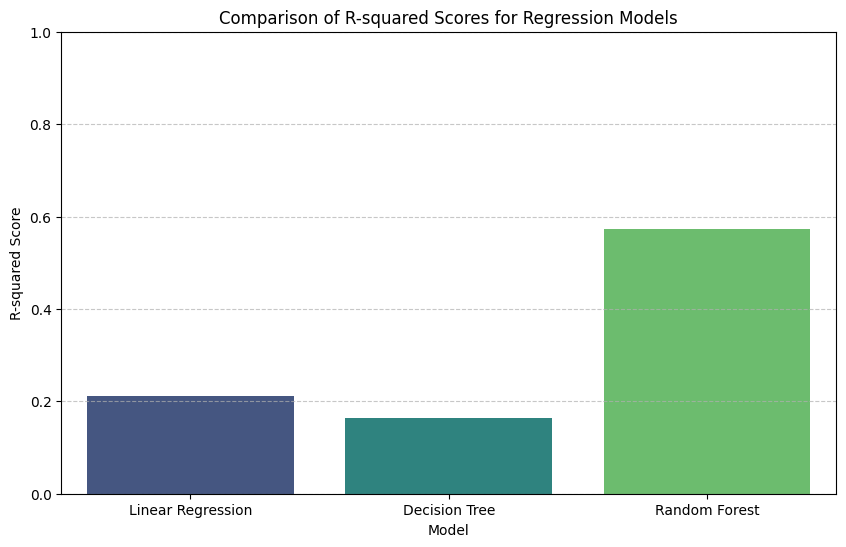

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
model_names = ['Linear Regression', 'Decision Tree', 'Random Forest']
r2_scores = [r2_linear, r2_dt, r2_rf]

# Create a DataFrame for easier plotting with seaborn
performance_df = pd.DataFrame({
    'Model': model_names,
    'R-squared': r2_scores
})

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R-squared', data=performance_df, palette='viridis')
plt.title('Comparison of R-squared Scores for Regression Models')
plt.ylabel('R-squared Score')
plt.xlabel('Model')
plt.ylim(0, 1) # R-squared typically ranges from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()